# Seller Performance & Marketplace Health

A marketplace lives and dies by its sellers. Too much concentration in a 
few big sellers is risky (what if they leave?). Too many small sellers with 
bad performance drags down the whole platform's reputation. This notebook 
looks at how revenue and quality are distributed across the seller base.

In [2]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

con = duckdb.connect()

DATA_PATH = r"C:\Users\UCWAcc\projects\ecommerce-analytics\data"

con.execute(f"""
    CREATE TABLE customers AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_customers_dataset.csv');
    CREATE TABLE orders AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_orders_dataset.csv');
    CREATE TABLE order_items AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_items_dataset.csv');
    CREATE TABLE products AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_products_dataset.csv');
    CREATE TABLE sellers AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_sellers_dataset.csv');
    CREATE TABLE reviews AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_order_reviews_dataset.csv');
    CREATE TABLE geolocation AS SELECT * FROM read_csv_auto('{DATA_PATH}/olist_geolocation_dataset.csv');
    CREATE TABLE category_translation AS SELECT * FROM read_csv_auto('{DATA_PATH}/product_category_name_translation.csv');
""")

def sql(query):
    return con.execute(query).fetchdf()

## Seller overview: how many are active and what do they sell?

In [4]:
seller_overview = sql("""
    SELECT COUNT(DISTINCT s.seller_id) AS total_sellers,
           COUNT(DISTINCT oi.product_id) AS unique_products,
           COUNT(DISTINCT oi.order_id) AS total_orders,
           ROUND(SUM(oi.price), 2) AS total_revenue,
           ROUND(SUM(oi.price) / COUNT(DISTINCT s.seller_id), 2) AS revenue_per_seller,
           ROUND(COUNT(DISTINCT oi.order_id) * 1.0 / COUNT(DISTINCT s.seller_id), 1) AS orders_per_seller
    FROM order_items oi
    JOIN sellers s ON oi.seller_id = s.seller_id
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
""")
seller_overview

,total_sellers,unique_products,total_orders,total_revenue,revenue_per_seller,orders_per_seller
0,2970,32216,96478,13221498.11,4451.68,32.5


## Revenue concentration across sellers

Same Pareto question as with product categories, but now for sellers. 
Is this a platform where everyone gets a slice, or do a few power 
sellers dominate?

In [6]:
seller_pareto = sql("""
    WITH seller_rev AS (
        SELECT oi.seller_id,
               ROUND(SUM(oi.price), 2) AS revenue,
               COUNT(DISTINCT oi.order_id) AS orders
        FROM order_items oi
        JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY oi.seller_id
    ),
    ranked AS (
        SELECT seller_id,
               revenue,
               orders,
               SUM(revenue) OVER (ORDER BY revenue DESC) AS running_total,
               SUM(revenue) OVER () AS grand_total,
               ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rank,
               COUNT(*) OVER () AS total_sellers
        FROM seller_rev
    )
    SELECT rank,
           seller_id,
           revenue,
           orders,
           ROUND(running_total / grand_total * 100, 1) AS cumulative_revenue_pct,
           ROUND(rank * 100.0 / total_sellers, 1) AS pct_of_sellers
    FROM ranked
    ORDER BY rank
    LIMIT 20
""")
seller_pareto

,rank,seller_id,revenue,orders,cumulative_revenue_pct,pct_of_sellers
0,1,4869f7a5dfa277a7dca6462dcf3b52b2,226987.93,1124,1.7,0.0
1,2,53243585a1d6dc2643021fd1853d8905,217940.44,348,3.4,0.1
2,3,4a3ca9315b744ce9f8e9374361493884,196882.12,1772,4.9,0.1
3,4,fa1c13f2614d7b5c4749cbc52fecda94,190917.14,578,6.3,0.1
4,5,7c67e1448b00f6e969d365cea6b010ab,186570.05,973,7.7,0.2
5,6,7e93a43ef30c4f03f38b393420bc753a,165981.49,319,9.0,0.2
6,7,da8622b14eb17ae2831f4ac5b9dab84a,159816.87,1311,10.2,0.2
7,8,7a67c85e85bb2ce8582c35f2203ad736,139658.69,1145,11.2,0.3
8,9,1025f0e2d44d7041d6cf58b6550e0bfa,138208.56,910,12.3,0.3
9,10,955fee9216a65b617aa5c0531780ce60,131836.71,1261,13.3,0.3


Let's find the 80% mark specifically:

In [8]:
pareto_80 = sql("""
    WITH seller_rev AS (
        SELECT oi.seller_id,
               ROUND(SUM(oi.price), 2) AS revenue
        FROM order_items oi
        JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY oi.seller_id
    ),
    ranked AS (
        SELECT seller_id,
               revenue,
               SUM(revenue) OVER (ORDER BY revenue DESC) AS running_total,
               SUM(revenue) OVER () AS grand_total,
               ROW_NUMBER() OVER (ORDER BY revenue DESC) AS rank,
               COUNT(*) OVER () AS total_sellers
        FROM seller_rev
    )
    SELECT MIN(rank) AS sellers_for_80pct,
           MIN(total_sellers) AS total_sellers,
           ROUND(MIN(rank) * 100.0 / MIN(total_sellers), 1) AS pct_of_sellers_for_80pct_revenue
    FROM ranked
    WHERE running_total / grand_total >= 0.8
""")
pareto_80

,sellers_for_80pct,total_sellers,pct_of_sellers_for_80pct_revenue
0,533,2970,17.9


## Seller tiers: segmenting by volume

Grouping sellers into tiers based on order volume gives a clearer 
picture than averages. The "long tail" of sellers with a handful 
of orders behaves very differently from the power sellers.

In [10]:
tiers = sql("""
    WITH seller_stats AS (
        SELECT oi.seller_id,
               COUNT(DISTINCT oi.order_id) AS orders,
               ROUND(SUM(oi.price), 2) AS revenue
        FROM order_items oi
        JOIN orders o ON oi.order_id = o.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY oi.seller_id
    )
    SELECT CASE
               WHEN orders <= 5 THEN '1-5 orders'
               WHEN orders <= 20 THEN '6-20 orders'
               WHEN orders <= 50 THEN '21-50 orders'
               WHEN orders <= 100 THEN '51-100 orders'
               ELSE '100+ orders'
           END AS tier,
           COUNT(*) AS num_sellers,
           ROUND(SUM(revenue), 2) AS tier_revenue,
           ROUND(AVG(revenue), 2) AS avg_seller_revenue,
           ROUND(AVG(orders), 1) AS avg_orders
    FROM seller_stats
    GROUP BY tier
    ORDER BY avg_orders
""")
tiers

,tier,num_sellers,tier_revenue,avg_seller_revenue,avg_orders
0,1-5 orders,1342,696805.55,519.23,2.3
1,6-20 orders,843,1711692.00,2030.48,10.9
2,21-50 orders,372,1904382.57,5119.31,32.7
3,51-100 orders,205,2061897.21,10058.04,71.4
4,100+ orders,208,6846720.78,32916.93,282.4


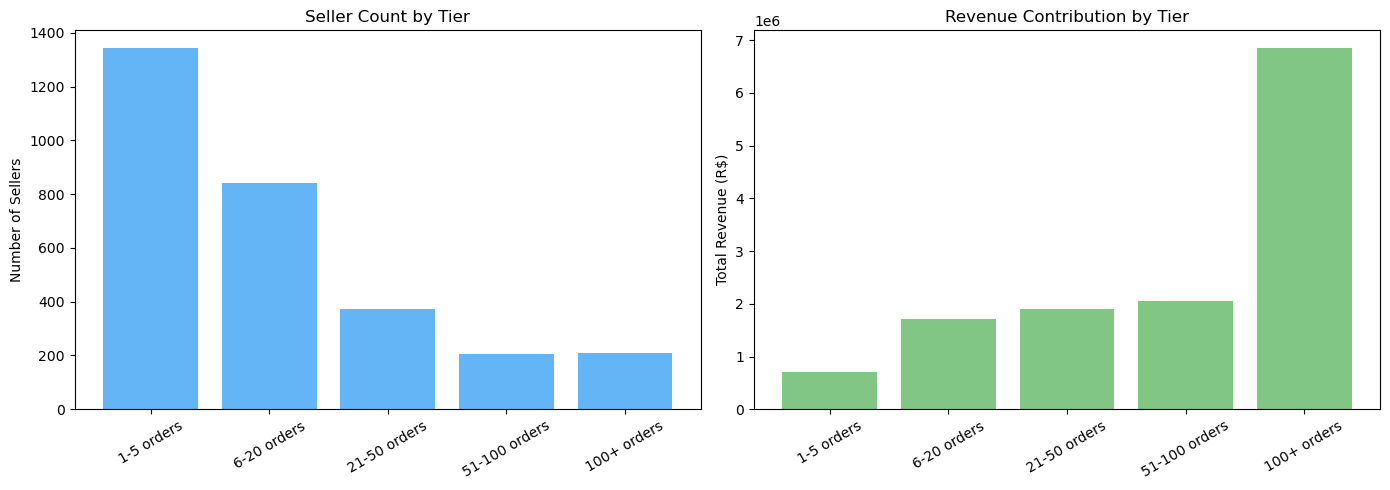

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(tiers['tier'], tiers['num_sellers'], color='#2196F3', alpha=0.7)
ax1.set_ylabel('Number of Sellers')
ax1.set_title('Seller Count by Tier')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

ax2.bar(tiers['tier'], tiers['tier_revenue'], color='#4CAF50', alpha=0.7)
ax2.set_ylabel('Total Revenue (R$)')
ax2.set_title('Revenue Contribution by Tier')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

plt.tight_layout()
plt.show()

## Seller quality: linking sellers to review scores

Which sellers consistently get good reviews, and which ones are dragging 
down the platform's reputation? This is actionable — low-rated sellers 
can be flagged for quality improvement or removal.

In [13]:
seller_quality = sql("""
    SELECT oi.seller_id,
           COUNT(DISTINCT oi.order_id) AS orders,
           ROUND(SUM(oi.price), 2) AS revenue,
           ROUND(AVG(r.review_score), 2) AS avg_review,
           SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END) AS bad_reviews,
           ROUND(SUM(CASE WHEN r.review_score <= 2 THEN 1 ELSE 0 END) * 100.0 
                 / COUNT(*), 1) AS bad_review_pct
    FROM order_items oi
    JOIN orders o ON oi.order_id = o.order_id
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY oi.seller_id
    HAVING COUNT(DISTINCT oi.order_id) >= 10
    ORDER BY avg_review ASC
    LIMIT 20
""")
seller_quality

,seller_id,orders,revenue,avg_review,bad_reviews,bad_review_pct
0,b1b3948701c5c72445495bd161b83a4c,14,21519.50,1.93,10.0,71.4
1,1ca7077d890b907f89be8c954a02686a,107,12324.64,2.27,80.0,63.5
2,5bc55dbe2f12b6af6d83ed46023e0dc8,17,2992.10,2.33,12.0,57.1
3,40db9e9aa57f7bb151bcda6b0f9bdbb7,11,21380.00,2.36,7.0,63.6
4,ecccfa2bb93b34a3bf033cc5d1dcdc69,12,1120.85,2.50,8.0,50.0
5,2709af9587499e95e803a6498a5a56e9,24,1081.56,2.60,26.0,57.8
6,c6a7539d424a8402232c2228d7a03c5e,10,607.50,2.60,8.0,53.3
7,bb135baca94c82fcb731335ad5b04a03,18,1049.80,2.66,20.0,52.6
8,02d35243ea2e497335cd0f076b45675d,14,5794.00,2.69,6.0,37.5
9,c26a2be5b53b7db6b276280da212a779,13,7482.00,2.72,10.0,55.6


And let's see the overall distribution of seller average ratings 
(for sellers with at least 10 orders, so we're not judging anyone 
on a handful of transactions):

In [15]:
rating_dist = sql("""
    WITH seller_ratings AS (
        SELECT oi.seller_id,
               COUNT(DISTINCT oi.order_id) AS orders,
               ROUND(AVG(r.review_score), 2) AS avg_review
        FROM order_items oi
        JOIN orders o ON oi.order_id = o.order_id
        JOIN reviews r ON o.order_id = r.order_id
        WHERE o.order_status = 'delivered'
        GROUP BY oi.seller_id
        HAVING COUNT(DISTINCT oi.order_id) >= 10
    )
    SELECT CASE
               WHEN avg_review >= 4.5 THEN 'Excellent (4.5+)'
               WHEN avg_review >= 4.0 THEN 'Good (4.0-4.4)'
               WHEN avg_review >= 3.5 THEN 'Average (3.5-3.9)'
               WHEN avg_review >= 3.0 THEN 'Below Avg (3.0-3.4)'
               ELSE 'Poor (<3.0)'
           END AS quality_tier,
           COUNT(*) AS num_sellers,
           ROUND(AVG(orders), 1) AS avg_orders
    FROM seller_ratings
    GROUP BY quality_tier
    ORDER BY quality_tier
""")
rating_dist

,quality_tier,num_sellers,avg_orders
0,Average (3.5-3.9),303,88.4
1,Below Avg (3.0-3.4),63,52.7
2,Excellent (4.5+),198,27.8
3,Good (4.0-4.4),657,83.7
4,Poor (<3.0),15,41.3


## Seller geography

Where are sellers based? Geographic clustering might explain delivery 
performance differences — if most sellers are in São Paulo but customers 
are in the northeast, that's a structural logistics challenge.

In [17]:
seller_geo = sql("""
    SELECT s.seller_state,
           COUNT(DISTINCT s.seller_id) AS sellers,
           COUNT(DISTINCT oi.order_id) AS orders,
           ROUND(SUM(oi.price), 2) AS revenue,
           ROUND(SUM(oi.price) / COUNT(DISTINCT s.seller_id), 2) AS revenue_per_seller
    FROM sellers s
    JOIN order_items oi ON s.seller_id = oi.seller_id
    JOIN orders o ON oi.order_id = o.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY s.seller_state
    ORDER BY revenue DESC
""")
seller_geo

,seller_state,sellers,orders,revenue,revenue_per_seller
0,SP,1769,68641,8509511.46,4810.35
1,PR,335,7512,1232096.99,3677.90
2,MG,236,7735,977866.31,4143.50
3,RJ,163,4227,820611.59,5034.43
4,SC,184,3603,613591.65,3334.74
5,RS,125,1962,373412.08,2987.30
6,BA,18,550,277925.51,15440.31
7,DF,30,808,94840.31,3161.34
8,PE,9,403,91164.15,10129.35
9,GO,39,451,64806.59,1661.71


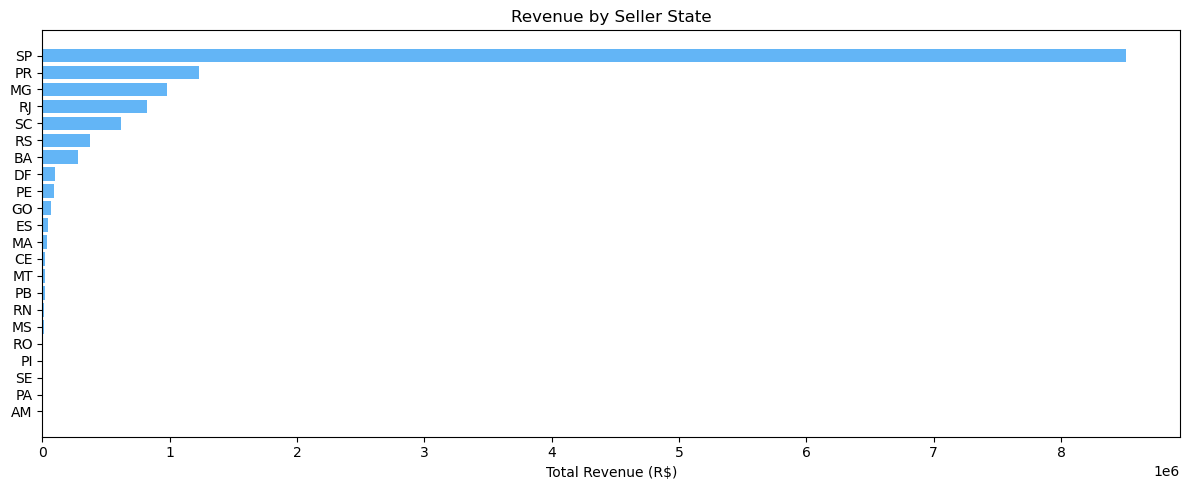

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(seller_geo['seller_state'][::-1], seller_geo['revenue'][::-1], color='#2196F3', alpha=0.7)
ax.set_xlabel('Total Revenue (R$)')
ax.set_title('Revenue by Seller State')
plt.tight_layout()
plt.show()

## Takeaways

**Classic Pareto distribution.** 18% of sellers (533 out of 2,970) generate 80% of revenue. This is healthy for a marketplace- concentrated enough to have clear power sellers, but not so extreme that losing one or two would be catastrophic. These top sellers should get priority support, dedicated account management, and retention incentives.

**São Paulo dominates everything.** SP accounts for ~60% of sellers and ~64% of total revenue ($8.5M out of $13.2M). The next closest state, Paraná, has R$1.2M. This extreme geographic concentration directly explains the delivery problems seen in Notebook 03 — customers in the north and northeast are structurally far from the supply base. Regional seller acquisition campaigns in underserved states could simultaneously improve delivery times and reduce geographic risk.

**The long tail is real.** Most sellers handle a modest volume of orders. The platform should track seller activation metrics — are newly onboarded sellers reaching their first 10 or 20 orders within 90 days? If not, the onboarding experience, discoverability, or seller support needs work. Dormant sellers are wasted acquisition cost.

**Quality varies and is measurable.** Review score distributions across sellers show clear outliers on both ends. Low-performing sellers with statistically meaningful order volumes should be flagged for quality review — they damage the platform's overall reputation. High performers should be studied for what they're doing right (packaging, communication, shipping speed) and those practices should be templated for others.
